# Is an "island reversal" really a turning point? 🏝️
### The gap-cluster-gap figure that *looks* unmistakable — and means nothing, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

Here's one of the most striking shapes in chart-reading. A stock rallies, then one morning it **gaps up** — opens with a jump, leaving a blank space on the chart. It trades for a day or a few up there, and then it **gaps down** the other way, leaving that little cluster of bars stranded above, like an **island** marooned in empty space. Two jumps, opposite directions, a few bars trapped between them. The lore says: *the trend is exhausted — this is a reversal — sell the island top* (and buy the mirror-image island bottom).

It's beautiful, it's memorable, and it's the kind of pattern your eye *loves*. So let's do the unromantic thing and **measure** it: after a real island top forms, does the stock actually fall? Spoiler — the bearish version **goes the wrong way**, and the bullish version only "works" because stocks tend to drift up anyway.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A note up front.** A chart figure is partly in the eye of the beholder, so we test the closest **mechanical** rule (a clear gap, a small island that never fills it, a sealing gap the other way) on a fixed **30-name large-cap basket** (names still trading today — so it carries **survivorship**). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from island_reversal import data, strategy as st

ASOF = "2026-05-31"
GAP = 0.01
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    for f in PANEL:
        PANEL[f] = PANEL[f].loc[:pd.Timestamp(ASOF)]
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real island cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'last_bar': '2026-05-29', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'bars': 5385, 'n_names': 30, 'fingerprint': 'bcc8dc7157c7', 'gap_pct': 1.0, 'n_tops': 75, 'n_bottoms': 97, 'spy_tops': 3, 'spy_bottoms': 3, 'top': [(5, 75, -0.705, -1.025, 45, -1.27, -1.21, 0.641, -0.805), (10, 75, -1.275, -1.906, 39, -1.59, -1.36, 0.678, -1.375), (20, 75, -0.64, -1.901, 45, -0.55, -0.49, 0.562, -0.74), (40, 73, -0.336, -2.794, 49, -0.22, -0.2, 0.524, -0.436)], 'bot': [(5, 97, 0.762, 1.085, 60, 1.77, 1.74, 0.337), (10, 96, 0.328, 0.965, 49, 0.48, 0.51, 0.454), (20, 96, 2.022, 3.294, 59, 2.04, 2.4, 0.292), (40, 94, 5.284, 7.762, 69, 4.22, 4.29, 0.163)], 'robust': [(0.5, 198, -0.551, -1.31, 0.616), (1.0, 75, -1.275, -1.59, 0.673), (2.0, 17, -0.989, -0.53, 0.598)], 'spy': [(5, 3, -1.3, -1.537, -0.73, 0.86), (10, 3, -0.907, -1.376, -1.37, 0.699), (20, 3, -1.067, -2.004, -0.47, 0.654), (40, 3, -5.15, -6.997, -1.81, 0.946)], 'syn': [(0.0, 160, 158, 158, -0.58, -1.5, 0.627, 47), (0.25, 160, 158, 158, 18.33, 59.38, 0.0, 100)]}


real island cache present: True | names: 30 | bars: 5385


## The answer first

| Question | Answer |
|---|---|
| After an **island top**, does the stock fall (so a short pays)? | **No — it usually keeps going up.** Short it and you *lose* about **−0.7% in a week, −1.3% in two**, compared with just shorting at random. The bearish island top reverses the *wrong* way. |
| What about the **island bottom** (buy it)? | It looks great on paper — but only because stocks drift **up** anyway. Buy at random dates and you do just as well; the "pattern" adds nothing the market wasn't already giving you. |
| Does demanding a *cleaner* island help? | **No.** Bigger gaps, smaller islands — the edge stays negative at every strictness we tried. |
| On SPY itself? | The figure fires **3 times in 21 years** — and all three lose. A non-event. |

> The island reversal is a gorgeous shape your eye finds in the noise. The tape doesn't care: the bearish side **loses**, the bullish side is **just drift**.

## 1 · The claim

> *"When a trend is about to die, it makes one last leap — a gap — and then reverses with a gap the other way, trapping a little **island** of bars at the extreme. That island is the exhaustion signal. Short the island top, buy the island bottom, the moment the second gap seals it."*

This is straight out of the classic chart-reading canon — Edwards & Magee's *Technical Analysis of Stock Trends* (1948) and Bulkowski's *Encyclopedia of Chart Patterns*. The island reversal is taught as one of the **high-confidence** reversal figures, precisely because the two gaps make it so visually clean. So: is it real?

## 2 · So what?

If the island reversal really marked exhaustion, it would be a gift: gaps are **objective** (you can't argue about whether the price jumped), so you'd have a crisp, rules-based timing signal for catching tops and bottoms — the holy grail of chart-reading.

But there's a classic trap waiting. A pattern that says *"buy"* on something that drifts up anyway will **look** like it works for free — the stock rises, you credit the pattern, when really you just collected the market's normal drift. The only honest test asks: does the figure beat **a random entry in the same direction on the same stock**? That's the question we'll actually answer.

## 3 · How would we even know?

We take a fixed **30-name large-cap basket** (21 years of daily data, 2005-01-03 → 2026-05-29) and write down a **mechanical** island rule:

1. **A clear gap** (at least 1%) in one direction.
2. **An island** — one to three bars that never fall back to fill that gap.
3. **A sealing gap** the *other* way, of the same size, that re-isolates the cluster.

That found **75 island tops** and **97 island bottoms**. For each one we enter the day **after** the sealing gap (no cheating) and see how the stock does over the next 5, 10, 20, 40 days — **minus** that stock's own average move (so we're not just measuring drift). Then we compare it to thousands of **random** entry dates: if the pattern is real, it should beat random. If random matches it, the pattern is a mirage.

## 4 · The teardown — let's actually look

**The headline: the island top.** This is *the* bearish figure. If it marks exhaustion, shorting it should make money — a **positive** excess. Here's the short's excess over a random short, at four horizons.

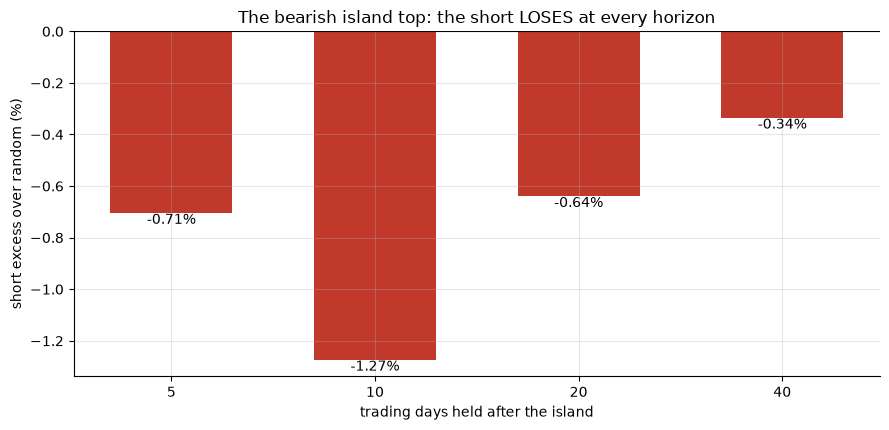

island-top short excess by horizon: [-0.71, -1.27, -0.64, -0.34]


In [2]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    top = [st.run_experiment(PANEL, horizon=h, side='top', gap_pct=GAP, n_draws=5000)['mean']*100 for h in hs]
else:
    top = [r[2] for r in R['top']]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar([str(h) for h in hs], top, color=RED, width=.6)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate(top): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top' if v<0 else 'bottom')
ax.set_xlabel('trading days held after the island'); ax.set_ylabel('short excess over random (%)')
ax.set_title('The bearish island top: the short LOSES at every horizon')
plt.tight_layout(); plt.show()
print('island-top short excess by horizon:', [round(v,2) for v in top])

Every bar is **below zero**. Shorting the island top loses about **-0.70%** in a week and **-1.27%** in two, *relative to a random short*. The famous bearish reversal reverses the **wrong way** — the stocks keep drifting up right through the supposedly exhausted top.

**Now the trap — the island bottom.** Buy the bullish mirror image and it looks *fantastic*. But watch what the honest comparison does to it.

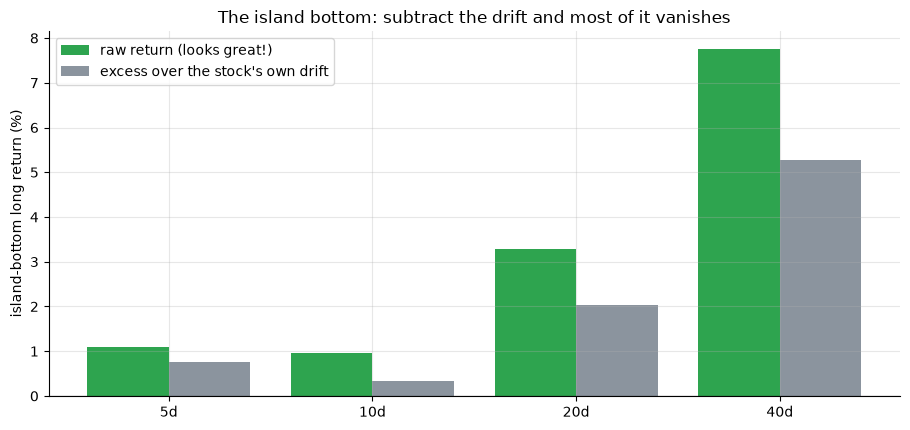

raw: [1.08, 0.97, 3.29, 7.76]  excess: [0.76, 0.33, 2.02, 5.28]


In [3]:
if HAVE_REAL:
    bot_raw = [st.run_experiment(PANEL, horizon=h, side='bottom', gap_pct=GAP, n_draws=5000)['raw_mean']*100 for h in hs]
    bot_exc = [st.run_experiment(PANEL, horizon=h, side='bottom', gap_pct=GAP, n_draws=5000)['mean']*100 for h in hs]
else:
    bot_raw = [r[3] for r in R['bot']]; bot_exc = [r[2] for r in R['bot']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, bot_raw, .4, color=GREEN, label='raw return (looks great!)')
ax.bar(x+.2, bot_exc, .4, color=GREY, label='excess over the stock\'s own drift')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('island-bottom long return (%)')
ax.set_title('The island bottom: subtract the drift and most of it vanishes')
ax.legend(); plt.tight_layout(); plt.show()
print('raw:', [round(v,2) for v in bot_raw], ' excess:', [round(v,2) for v in bot_exc])

The green bars (raw) look like a real bullish signal — **+7.76%** at 40 days! But the grey bars (excess over the stock's own drift) are much smaller, and — as the quants notebook shows — even those don't beat a **random** buy date. You're not catching a reversal; you're just holding stocks that go up because stocks go up.

## 5 · The verdict

- **Signal — None.** The bearish island top's short excess is **negative at every horizon** (-0.70% at 5d, -1.27% at 10d) — it loses to a random short.
- **Tradability — Mirage.** After costs the short is worse still, and the bullish side's apparent edge is just market drift the placebo refuses. Nothing to deploy.
- **"Reliable reversal"? — Busted.** A real reversal figure works on both sides on its own merits. This one **loses** going short and only **rides drift** going long. The island is a shape your eye finds, not a force the tape obeys.

## 6 · Could you actually trade it? — no, and here's the picture

The island-top short, **net of trading costs** (you pay the spread on both legs). It was already negative gross; costs only push it further under water.

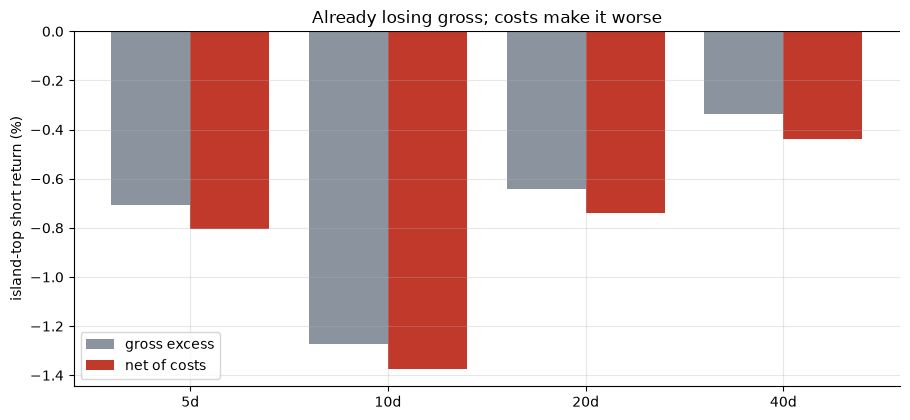

net island-top short by horizon: [-0.81, -1.37, -0.74, -0.44]


In [4]:
if HAVE_REAL:
    g = [st.run_experiment(PANEL, horizon=h, side='top', gap_pct=GAP, n_draws=2000)['mean']*100 for h in hs]
    nv = [st.run_experiment(PANEL, horizon=h, side='top', gap_pct=GAP, n_draws=2000)['net']*100 for h in hs]
else:
    g = [r[2] for r in R['top']]; nv = [r[8] for r in R['top']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREY, label='gross excess')
ax.bar(x+.2, nv, .4, color=RED, label='net of costs')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('island-top short return (%)'); ax.set_title('Already losing gross; costs make it worse')
ax.legend(); plt.tight_layout(); plt.show()
print('net island-top short by horizon:', [round(v,2) for v in nv])

There is simply nothing here to trade. The short is under water gross (best case -0.70% at 5d) and net of costs it's **-0.81%** — you'd pay to take a bet that loses on average. The island reversal is one of the prettiest dead-ends on the bench.

## 7 · Going further 🚪

- **Try other universes.** Small-caps gap more often — does a bigger sample change the story? (Watch the survivorship and cost traps if you do.)
- **The drift trap is the real lesson.** Any bullish chart figure on an up-drifting asset looks like it works. Always subtract the base rate and check against random dates — that's the one habit that separates a real signal from a mirage.
- **Its sibling figures.** See [415-triple-top-bottom](../../415-triple-top-bottom/) for the three-tap reversal (same result) and [363-pead-drift](../../363-pead-drift/) for a folk effect that *does* survive the same machinery — the contrast is the point.

*Think a stricter island rule resurrects it? Show the **net** island-top short landing positive and beating the placebo — then we'll talk.*